### Step1. 실습 환경 & 공통 함수 정의

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [2]:
def make_harder_mlp_data(
    n_samples=2000,
    noise=0.25,
    train_ratio=0.15,
    val_ratio=0.35,
    n_noise_features=50,
    spurious_strength=3.0,
    train_spurious_corr=0.95,
    test_spurious_corr=0.50,
    random_state=42
):
    np.random.seed(random_state)

    # 1. 기본 비선형 분류 데이터
    X2, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    y = y.astype(np.float32)

    # 2. train / val / test 분할
    X_train, X_temp, y_train, y_temp = train_test_split(
        X2, y, test_size=(1 - train_ratio), stratify=y, random_state=random_state
    )

    val_portion = val_ratio / (1 - train_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_portion),
        stratify=y_temp, random_state=random_state
    )

    # 3. 고차원 noise feature 추가
    def add_noise_features(X, n_noise):
        noise_feat = np.random.randn(len(X), n_noise)
        return np.concatenate([X, noise_feat], axis=1)

    X_train = add_noise_features(X_train, n_noise_features)
    X_val   = add_noise_features(X_val, n_noise_features)
    X_test  = add_noise_features(X_test, n_noise_features)

    # 4. spurious feature 추가
    def make_spurious_feature(y, corr, strength):
        aligned = y.copy()
        flip_mask = np.random.rand(len(y)) > corr
        aligned[flip_mask] = 1 - aligned[flip_mask]
        spurious = (2 * aligned - 1) * strength + np.random.randn(len(y)) * 0.5
        return spurious.reshape(-1, 1)

    s_train = make_spurious_feature(y_train, train_spurious_corr, spurious_strength)
    s_val   = make_spurious_feature(y_val, test_spurious_corr, spurious_strength)
    s_test  = make_spurious_feature(y_test, test_spurious_corr, spurious_strength)

    X_train = np.concatenate([X_train, s_train], axis=1)
    X_val   = np.concatenate([X_val, s_val], axis=1)
    X_test  = np.concatenate([X_test, s_test], axis=1)

    # 5. 표준화
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).view(-1, 1),
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32).view(-1, 1),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32).view(-1, 1),
    )


# Part 1. 가중치 감쇠와 조기 종료

과적합을 직접 만들고 patience 조정

#### Step 1. 2D moons 데이터 생성 및 분할

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = make_harder_mlp_data(
    n_samples=2000,
    noise=0.30,
    train_ratio=0.12,
    val_ratio=0.38,
    n_noise_features=80,
    spurious_strength=3.5,
    train_spurious_corr=0.97,
    test_spurious_corr=0.55,
    random_state=42
)

X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val     = X_val.to(device), y_val.to(device)
X_test, y_test   = X_test.to(device), y_test.to(device)

print("train:", X_train.shape, y_train.shape)
print("val  :", X_val.shape, y_val.shape)
print("test :", X_test.shape, y_test.shape)


train: torch.Size([240, 83]) torch.Size([240, 1])
val  : torch.Size([760, 83]) torch.Size([760, 1])
test : torch.Size([1000, 83]) torch.Size([1000, 1])


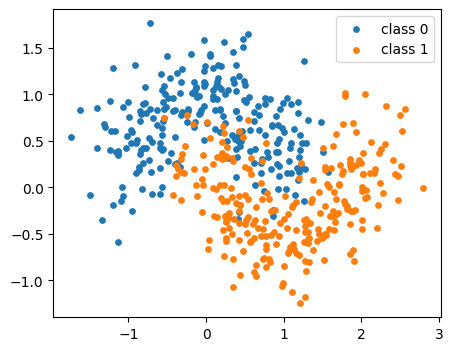

In [4]:
X2, y2 = make_moons(n_samples=500, noise=0.30, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X2[y2==0, 0], X2[y2==0, 1], s=15, label="class 0")
plt.scatter(X2[y2==1, 0], X2[y2==1, 1], s=15, label="class 1")
plt.legend()
plt.show()


#### Step 2. baseline MLP와 공통 학습 함수 정의

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=256, depth=3, dropout=0.0, residual=False):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden, hidden) for _ in range(depth - 1)
        ])
        self.output_layer = nn.Linear(hidden, 1)
        self.dropout = nn.Dropout(dropout)
        self.residual = residual

    def forward(self, x):
        h = F.relu(self.input_layer(x))
        h = self.dropout(h)

        for layer in self.hidden_layers:
            new_h = F.relu(layer(h))
            if self.residual and new_h.shape == h.shape:
                h = new_h + h
            else:
                h = new_h
            h = self.dropout(h)

        out = self.output_layer(h)
        return out


#### Step 3-1. Weight Decay sweep 실험

In [6]:
@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    loss = F.binary_cross_entropy_with_logits(logits, y)
    pred = (torch.sigmoid(logits) > 0.5).float()
    acc = (pred == y).float().mean().item()
    return loss.item(), acc

In [7]:
def train_model(
    model, X_train, y_train, X_val, y_val,
    lr=1e-3, epochs=300,
    weight_decay=0.0,
    l1_lambda=0.0,
    early_stopping=False,
    patience=20
):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    best_val_loss = float("inf")
    best_state = deepcopy(model.state_dict())
    wait = 0

    for epoch in range(epochs):
        model.train()
        logits = model(X_train)
        loss = F.binary_cross_entropy_with_logits(logits, y_train)

        if l1_lambda > 0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters() if p.ndim > 1)
            loss = loss + l1_lambda * l1_penalty

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss, train_acc = evaluate(model, X_train, y_train)
        val_loss, val_acc = evaluate(model, X_val, y_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if early_stopping and wait >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model, history


#### Step 3-2. Baseline 모델 학습

In [8]:
input_dim = X_train.shape[1]

baseline = MLP(input_dim=input_dim, hidden=256, depth=4, dropout=0.0, residual=False)
baseline, hist_base = train_model(
    baseline, X_train, y_train, X_val, y_val,
    lr=1e-3, epochs=400,
    weight_decay=0.0,
    early_stopping=False
)

test_loss, test_acc = evaluate(baseline, X_test, y_test)
print("Baseline test acc:", test_acc)


Baseline test acc: 0.6909999847412109


#### Step 3-3. Baseline 학습 히스토리 시각화

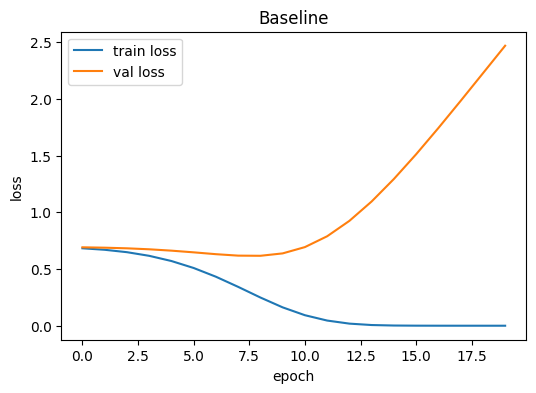

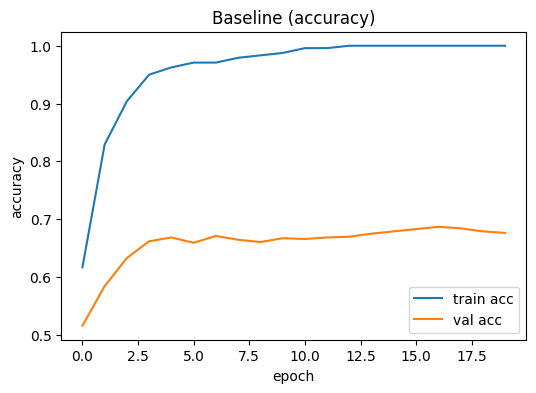

In [9]:
def plot_history(hist, title="history"):
    plt.figure(figsize=(6,4))
    plt.plot(hist["train_loss"][:20], label="train loss")
    plt.plot(hist["val_loss"][:20], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(hist["train_acc"][:20], label="train acc")
    plt.plot(hist["val_acc"][:20], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " (accuracy)")
    plt.legend()
    plt.show()

plot_history(hist_base, "Baseline")


#### Step 3-4. Weight Decay sweep 실험

In [10]:
wd_results = {}

for wd in [1e-5, 1e-4, 1e-3, 1e-2]:
    model = MLP(input_dim=input_dim, hidden=256, depth=4, dropout=0.0, residual=False)
    model, hist = train_model(
        model, X_train, y_train, X_val, y_val,
        lr=1e-3, epochs=400,
        weight_decay=wd
    )
    _, test_acc = evaluate(model, X_test, y_test)
    wd_results[wd] = {"model": model, "hist": hist, "test_acc": test_acc}
    print(f"weight_decay={wd:.0e}, test_acc={test_acc:.4f}")


weight_decay=1e-05, test_acc=0.6670
weight_decay=1e-04, test_acc=0.7140
weight_decay=1e-03, test_acc=0.6880
weight_decay=1e-02, test_acc=0.7200


#### Step 3-5. Weight Decay sweep 결과 시각화

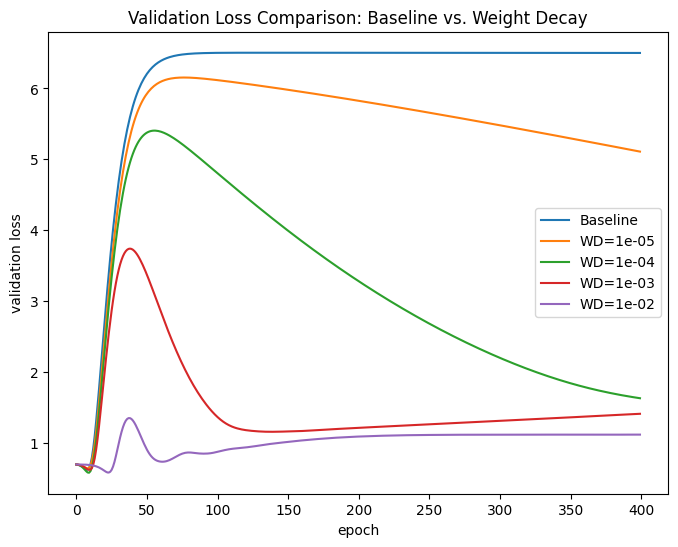

In [11]:
plt.figure(figsize=(8,6))
plt.plot(hist_base["val_loss"], label="Baseline")

for wd, result in wd_results.items():
    plt.plot(result["hist"]["val_loss"], label=f"WD={wd:.0e}")

plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("Validation Loss Comparison: Baseline vs. Weight Decay")
plt.legend()
plt.show()


#### Step 4. L1 vs L2 직접 비교

In [12]:
l1_model = MLP(input_dim=input_dim, hidden=256, depth=4)
l1_model, hist_l1 = train_model(
    l1_model, X_train, y_train, X_val, y_val,
    lr=1e-3, epochs=400,
    l1_lambda=1e-5
)

l2_model = MLP(input_dim=input_dim, hidden=256, depth=4)
l2_model, hist_l2 = train_model(
    l2_model, X_train, y_train, X_val, y_val,
    lr=1e-3, epochs=1000,
    weight_decay=1e-3
)

print("L1 test acc:", evaluate(l1_model, X_test, y_test)[1])
print("L2 test acc:", evaluate(l2_model, X_test, y_test)[1])


L1 test acc: 0.7120000123977661
L2 test acc: 0.6919999718666077


#### Step 5-1. Early Stopping 구현

In [13]:
es_model = MLP(input_dim=input_dim, hidden=256, depth=4, dropout=0.0)
es_model, hist_es = train_model(
    es_model, X_train, y_train, X_val, y_val,
    lr=1e-3, epochs=400,
    early_stopping=True, patience=20
)

print("EarlyStopping test acc:", evaluate(es_model, X_test, y_test)[1])


Early stopping at epoch 30
EarlyStopping test acc: 0.7089999914169312


#### Step 5-2. Early stopping - patience 비교

In [14]:
patience_results = {}

for p in [5, 10, 20, 40]:
    model = MLP(input_dim=input_dim, hidden=256, depth=4)
    model, hist = train_model(
        model, X_train, y_train, X_val, y_val,
        lr=1e-3, epochs=400,
        early_stopping=True, patience=p
    )
    _, test_acc = evaluate(model, X_test, y_test)
    patience_results[p] = test_acc
    print(f"patience={p}, test_acc={test_acc:.4f}")


Early stopping at epoch 15
patience=5, test_acc=0.7010
Early stopping at epoch 19
patience=10, test_acc=0.6900
Early stopping at epoch 29
patience=20, test_acc=0.6880
Early stopping at epoch 49
patience=40, test_acc=0.6990


#### Step 5-2. Early Stopping 결과 시각화

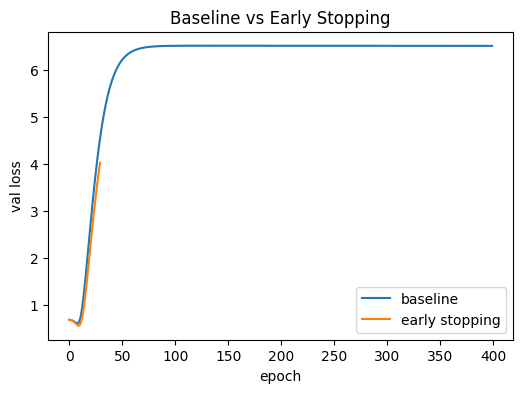

In [15]:
plt.figure(figsize=(6,4))
plt.plot(hist_base["val_loss"], label="baseline")
plt.plot(hist_es["val_loss"], label="early stopping")
plt.xlabel("epoch")
plt.ylabel("val loss")
plt.title("Baseline vs Early Stopping")
plt.legend()
plt.show()


# Part 2. 드롭아웃과 예측 불확실성

#### Step 1. Dropout train/eval 동작 확인

In [16]:
drop_model = MLP(input_dim=input_dim, hidden=256, depth=4, dropout=0.5)
drop_model, hist_drop = train_model(
    drop_model, X_train, y_train, X_val, y_val,
    lr=1e-3, epochs=400
)

print("Dropout test acc:", evaluate(drop_model, X_test, y_test)[1])


Dropout test acc: 0.7110000252723694


#### Step 2. MC Dropout으로 불확실성 보기

In [17]:
x_sample = X_test[:5]

drop_model.train()
out1 = torch.sigmoid(drop_model(x_sample))
out2 = torch.sigmoid(drop_model(x_sample))

drop_model.eval()
out3 = torch.sigmoid(drop_model(x_sample))
out4 = torch.sigmoid(drop_model(x_sample))

print("train mode difference:", (out1 - out2).abs().mean().item())
print("eval mode difference :", (out3 - out4).abs().mean().item())


train mode difference: 0.12442972511053085
eval mode difference : 0.0


# Part 3. Skip Connection과 기울기 소실 해결 실험

각 활성함수별 MLP에 Skip connection을 추가하여 그라디언트 복원 효과 기대하기

#### Step 0-1. Deep MLP 클래스 정의

In [18]:
from collections import OrderedDict

class DeepMLP(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128,
                 num_hidden=12, output_dim=2, activation="sigmoid"):
        super().__init__()
        layers = []
        in_dim = input_dim
        for i in range(num_hidden):
            layers.append((f"linear_{i+1}", nn.Linear(in_dim, hidden_dim)))
            if activation == "sigmoid":
                layers.append((f"act_{i+1}", nn.Sigmoid()))
            elif activation == "relu":
                layers.append((f"act_{i+1}", nn.ReLU()))
            else:
                raise ValueError("activation must be 'sigmoid' or 'relu'")
            in_dim = hidden_dim
        layers.append(("output", nn.Linear(hidden_dim, output_dim)))
        self.net = nn.Sequential(OrderedDict(layers))
        self.activation = activation
        self._initialize_weights()

    def _initialize_weights(self):
        # 활성함수 특성에 맞춰 초기화
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if self.activation == "sigmoid":
                    nn.init.xavier_normal_(m.weight)
                elif self.activation == "relu":
                    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


#### Step 0-2. 레이어별 그라디언트 노름 추출 함수

In [19]:
def get_layer_grad_norms(model):
    grad_norms, layer_names = [], []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            if module.weight.grad is not None:
                grad_norm = module.weight.grad.norm().item()
            else:
                grad_norm = 0.0
            grad_norms.append(grad_norm)
            layer_names.append(name)
    return layer_names, grad_norms


#### Step 1. Skip Connection 포함 모델 정의

In [20]:
class DeepMLPWithSkip(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128,
                 num_hidden=12, output_dim=2, activation="sigmoid"):
        super().__init__()
        self.activation_name = activation
        act_fn = nn.Sigmoid if activation == "sigmoid" else nn.ReLU

        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.input_act   = act_fn()

        self.hidden_linears = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(num_hidden - 1)]
        )
        self.hidden_acts = nn.ModuleList(
            [act_fn() for _ in range(num_hidden - 1)]
        )
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if self.activation_name == "relu":
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_act(self.input_layer(x))
        for linear, act in zip(self.hidden_linears, self.hidden_acts):
            residual = x                # skip connection
            x = act(linear(x)) + residual
        return self.output_layer(x)


#### Step 2. 기존 MLP vs Skip Connection MLP 비교

In [21]:
def run_skip_connection_experiment():
    x = torch.randn(32, 64).to(device)
    y = torch.randint(0, 2, (32,)).to(device)
    criterion = nn.CrossEntropyLoss()

    # 4가지 모델: 기존 Sigmoid/ReLU, Skip Connection Sigmoid/ReLU
    configs = {
        "Sigmoid":      DeepMLP(activation="sigmoid"),
        "ReLU":         DeepMLP(activation="relu"),
        "Sigmoid+Skip": DeepMLPWithSkip(activation="sigmoid"),
        "ReLU+Skip":    DeepMLPWithSkip(activation="relu"),
    }

    results = {}
    for name, model in configs.items():
        model = model.to(device)
        loss = criterion(model(x), y)
        loss.backward()
        layer_names, grads = get_layer_grad_norms(model)
        results[name] = grads
        print(f"[{name}] grad norms: {[f'{g:.4e}' for g in grads]}")

    return layer_names, results

layer_names, results = run_skip_connection_experiment()


[Sigmoid] grad norms: ['5.6431e-08', '5.2902e-07', '2.0369e-06', '8.7010e-06', '3.6959e-05', '1.3442e-04', '5.2707e-04', '2.6205e-03', '1.0366e-02', '4.4189e-02', '2.0321e-01', '7.9606e-01', '2.3566e+00']
[ReLU] grad norms: ['1.2170e+00', '1.8906e+00', '2.0076e+00', '2.2633e+00', '2.6081e+00', '2.7352e+00', '3.4648e+00', '4.0573e+00', '3.5709e+00', '3.5059e+00', '4.4484e+00', '4.2964e+00', '4.3300e+00']
[Sigmoid+Skip] grad norms: ['3.6380e-01', '1.1720e+00', '2.0030e+00', '2.6005e+00', '3.2696e+00', '3.4688e+00', '3.5965e+00', '5.3880e+00', '3.7418e+00', '4.9581e+00', '5.9509e+00', '6.1414e+00', '4.0890e+01']
[ReLU+Skip] grad norms: ['5.5679e+01', '8.5850e+01', '1.3324e+02', '1.9648e+02', '2.6660e+02', '3.6516e+02', '5.0706e+02', '6.9351e+02', '9.3464e+02', '1.0444e+03', '1.3920e+03', '1.7723e+03', '2.6765e+03']


#### Step 3. Skip  Connection 효과 시각화

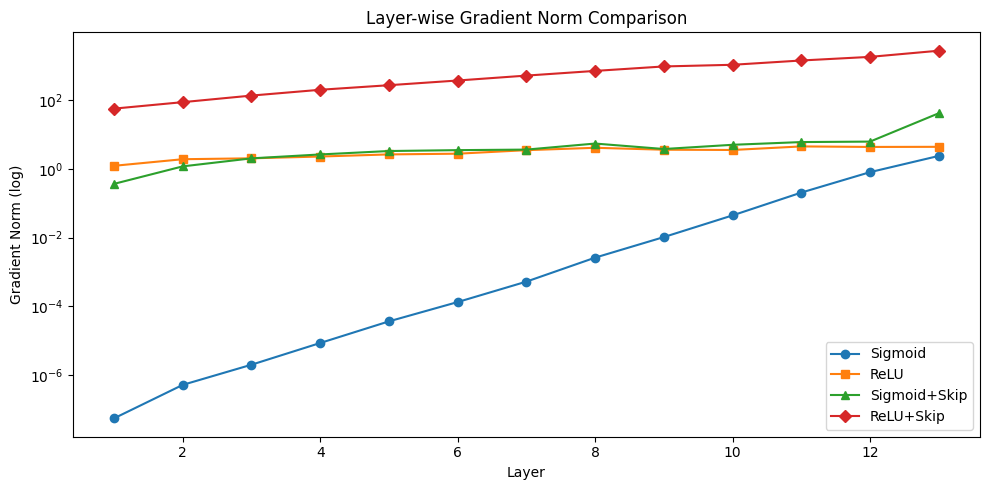

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
markers = {'Sigmoid': 'o', 'ReLU': 's',
           'Sigmoid+Skip': '^', 'ReLU+Skip': 'D'}
colors  = {'Sigmoid': 'C0', 'ReLU': 'C1',
           'Sigmoid+Skip': 'C2', 'ReLU+Skip': 'C3'}

for name, grads in results.items():
    ax.plot(range(1, len(grads)+1), grads,
           marker=markers[name], label=name, color=colors[name])

ax.set_yscale('log')
ax.set_xlabel('Layer')
ax.set_ylabel('Gradient Norm (log)')
ax.set_title('Layer-wise Gradient Norm Comparison')
ax.legend()
plt.tight_layout(); plt.show()
